In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import pandas as pd
import regionmask as rm
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")

## Fig. S1 - Seasonal Insolation Anomaly

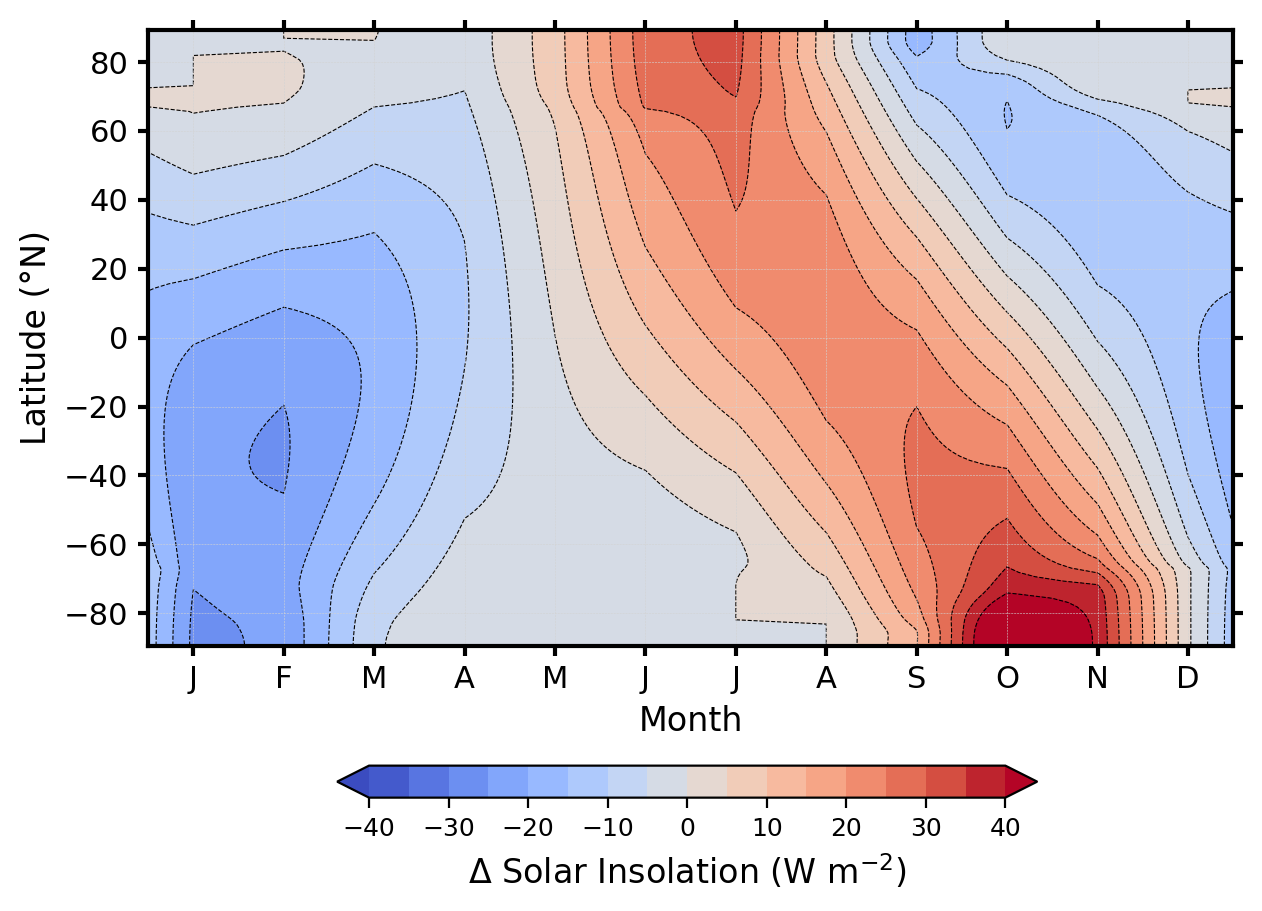

In [ ]:
#------------------------------------------------------------
# Calculate Anomaly
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

plt_time = np.arange(14)
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

cmap = cm.coolwarm; v = 40; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Solar Insolation (W $\mathregular{m^{-2}}$)"

del_sw_in = (MH_means['toa_sw_in'] - PI_means['toa_sw_in']).mean(dim="longitude").transpose()
del_sw_in = xr.concat(
    [del_sw_in.isel(time=-1), del_sw_in, del_sw_in.isel(time=0)], dim="time"
)

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

fig, ax = plt.subplots(figsize = (7, 4), dpi=200)

f1 = ax.contourf(plt_time, del_sw_in.latitude, del_sw_in, extend="both", cmap=cmap, levels=levs, zorder=0)
c1 = ax.contour(plt_time, del_sw_in.latitude, del_sw_in, extend="both", colors="k", linestyles="dashed", linewidths=0.4, levels=levs, zorder=0)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Latitude (°N)", fontsize=12)
ax.set_xticks(np.arange(1, 13), labels=xticklabs)
ax.set_xlim((0.5, 12.5))
ax.xaxis.set_ticks_position("both")
ax.yaxis.set_ticks_position("both")
ax.grid(True, color="lightgrey", ls="--", lw=0.2, zorder=10)
ax.tick_params("both", width=1.5, labelsize=11)

cbaxes = fig.add_axes((0.26, -0.08, 0.5, 0.04))
cbar = plt.colorbar(f1, extend='both', orientation='horizontal', ticks=levs[::2], cax=cbaxes)
cbar.ax.tick_params(labelsize=9) 
cbar.set_label(label=cbar_lab, size=12)

for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.5)

plt.show()

## Fig. 2 - Seasonal Climate Anomalies (JJA & DJF)

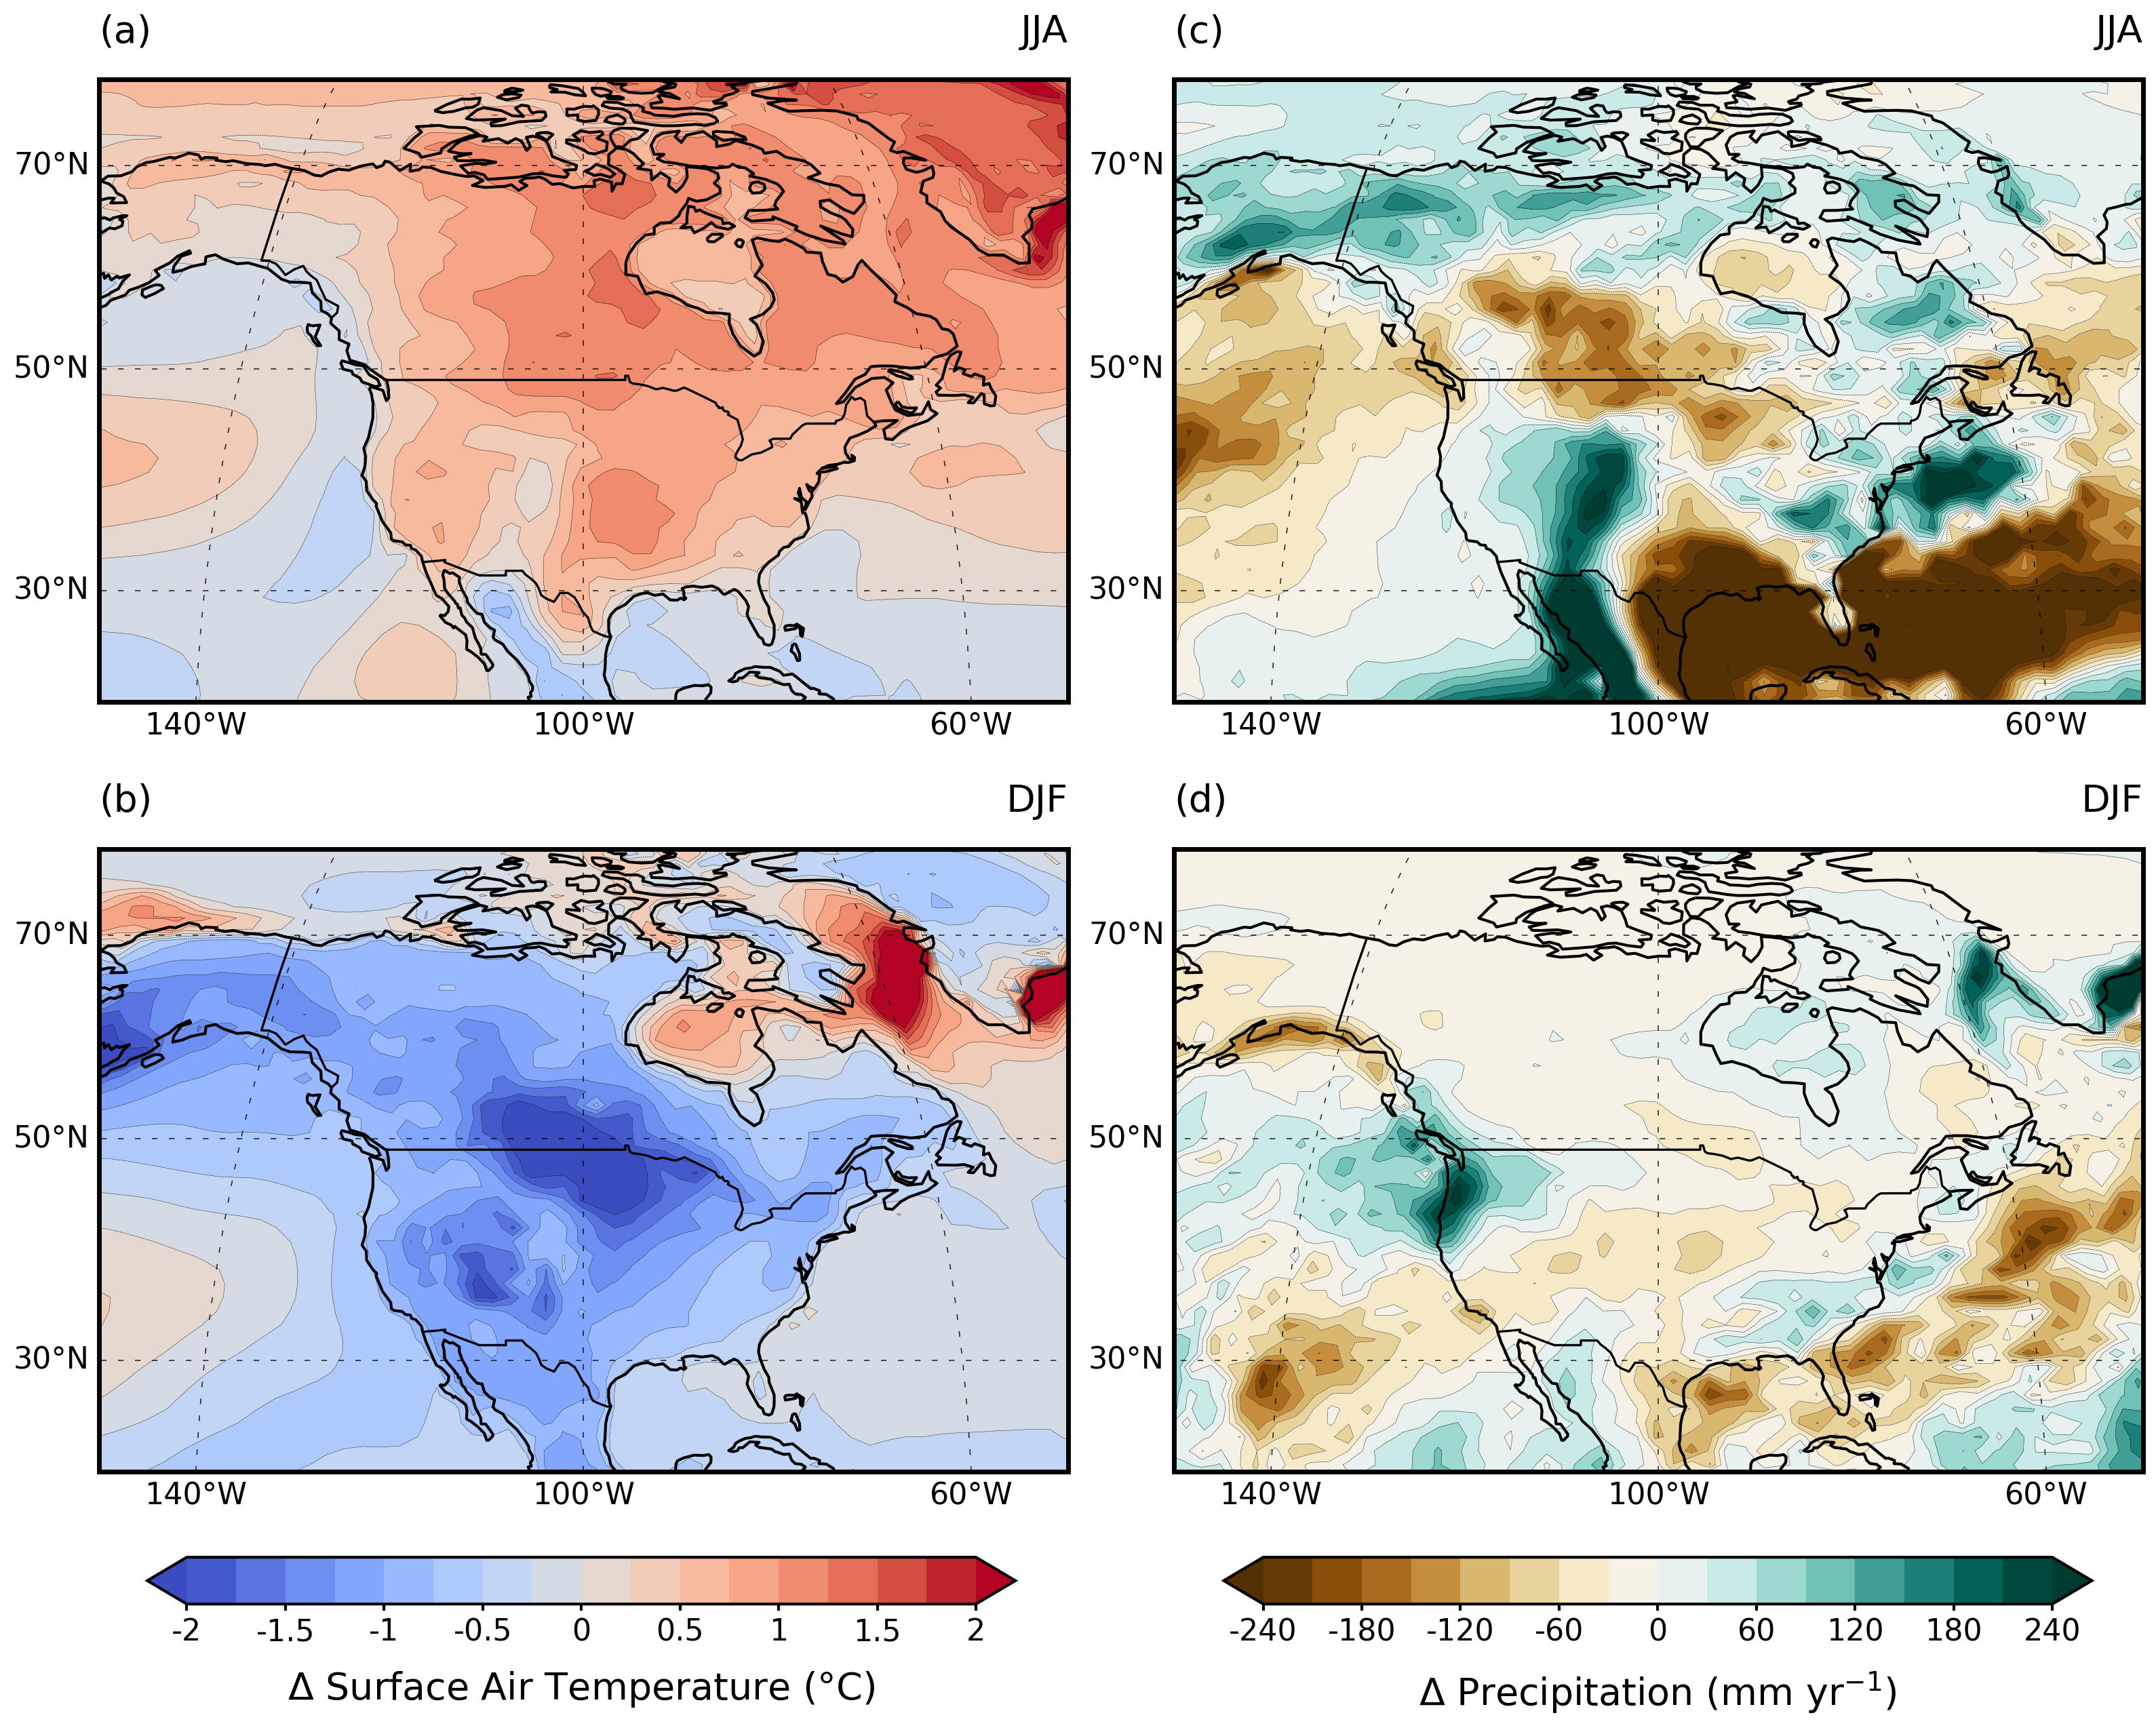

In [ ]:
#------------------------------------------------------------
# Calculate anomalies
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

ukesm_pr = (MH_means["pr"] - PI_means["pr"]) * 12 # Convert to mm/yr
ukesm_tas = MH_means["tas"] - PI_means["tas"]

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

fig = plt.figure(figsize=(16, 11.5), dpi=200)
gs = GridSpec(2, 2)

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)
LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)

cfg = [
    dict(
        data=ukesm_tas, cmap=cm.coolwarm, v=2,
        cbar_lab=r"$\Delta$ Surface Air Temperature (°C)",
        cbax=(0.071, -0.04, 0.4, 0.03),
        label=["a", "b"],
    ),
    dict(
        data=ukesm_pr, cmap=cm.BrBG, v=240,
        cbar_lab=r"$\Delta$ Precipitation (mm $\mathregular{yr^{-1}}$)",
        cbax=(0.567, -0.04, 0.4, 0.03),
        label=["c", "d"],
    ),
]

seasons = {
    "JJA": [5, 6, 7],
    "DJF": [11, 0, 1]
}

for j, c in enumerate(cfg):
    levs = np.linspace(-c["v"], c["v"], 17)

    for k, (season, idx) in enumerate(seasons.items()):
        ann = c["data"].isel(time=idx).mean(dim="time")

        ax = plt.subplot(gs[k, j], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=1.5, spinelw=2.5, bordercol="black", borderlw=1.2)
        umplt.plotGrid(ax, xlabeledlines=[-140, -100, -60], ylabeledlines=[30, 50, 70],
                       labelsize=16, lw=0.6)

        cf = ax.contourf(LON, LAT, ann, extend="both", levels=levs, cmap=c["cmap"],
                         transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
        ax.contour(LON, LAT, ann, levels=levs, colors="black", linestyles="dashed",
                   linewidths=0.2, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

        ax.set_title(f"({c['label'][k]})", loc="left", fontsize=20, pad=20)
        ax.set_title(season, loc="right", fontsize=20, pad=20)

    ticks = np.linspace(-c["v"], c["v"], 9)
    cbar = plt.colorbar(cf, orientation="horizontal", cax=fig.add_axes(c["cbax"]))
    cbar.outline.set_linewidth(1.5)
    cbar.set_ticks(ticks, labels=[f"{x:g}" for x in ticks], fontsize=16)
    cbar.ax.tick_params(width=1.5)
    cbar.set_label(label=c["cbar_lab"], size=20, labelpad=12)

plt.tight_layout()
plt.show()


## Fig. S3 - RMSE scores and subregions

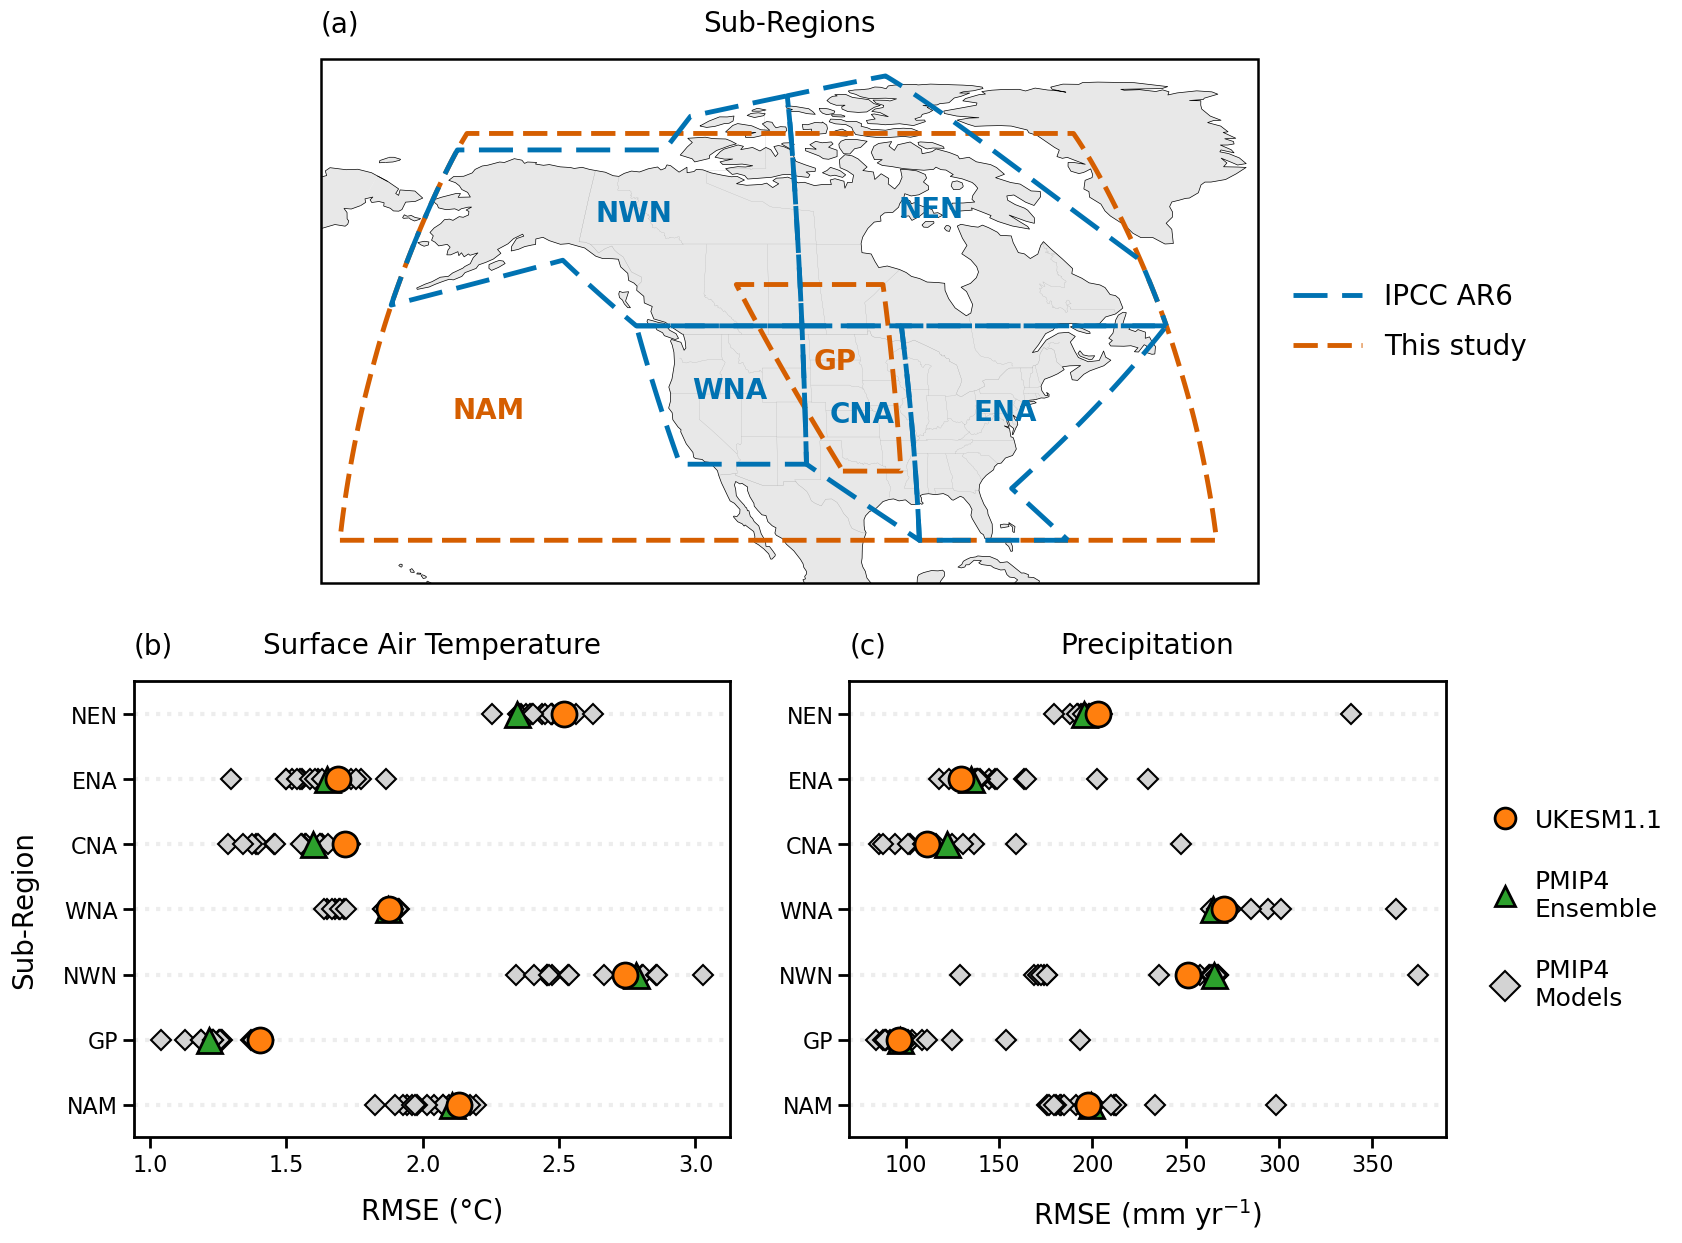

In [ ]:
#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

PANELS = [
    ("tas", "RMSE (°C)",                          "Surface Air Temperature"),
    ("pr",  r"RMSE (mm $\mathregular{yr^{-1}}$)", "Precipitation"),
]

RMSE_ORDER  = ["NAM", "GP", "NWN", "WNA", "CNA", "ENA", "NEN"]   # bottom -> top
MAP_REGIONS = ["NAM", "GP", "WNA", "CNA", "ENA", "NWN", "NEN"]
UM_REGIONS  = {"NAM", "GP"}

SERIES = {
    "UKESM1.1":        dict(marker="o", mfc="tab:orange", ms=18, mew=2.0, zorder=3),
    "PMIP4\nEnsemble": dict(marker="^", mfc="tab:green",  ms=18, mew=2.0, zorder=2),
    "PMIP4\nModels":   dict(marker="D", mfc="lightgrey",  ms=10, mew=1.5, zorder=1),
}
BASE = dict(linestyle="None", mec="black")

FS = dict(label=20, tick=16, title=20, legend=18, region=20)

fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 7, figure=fig, height_ratios=[1.15, 1], hspace=0.20, wspace=1.0)

#------------------------------------------------------------
# Panel (a) - Subregions
#------------------------------------------------------------

ax = fig.add_subplot(gs[0, 0:6], projection=ccrs.Robinson(central_longitude=-112.5))
umplt.plotBaseMap(ax, [-170, -45, 20, 90], coastlw=0.5, land=True,
                  landcol="lightgray", landalph=0.5, spinelw=1.8,
                  states=True, statelinecol="grey", statelw=0.1)

REGION_STYLE = {
    True:  dict(color="#D55E00", linestyle=(0, (5, 2))),   # this study (NAM, GP)
    False: dict(color="#0072B2", linestyle=(0, (7, 3))),   # IPCC AR6
}

for name in MAP_REGIONS:
    is_um  = name in UM_REGIONS
    region = umplt.umRegion(name) if is_um else rm.defined_regions.ar6.all[[name]]
    style = REGION_STYLE[is_um]

    line_kws = {**style, "linewidth": 3.5}
    text_kws = {"fontsize": FS["region"], "fontweight": "bold",
                "bbox": None, "color": style["color"]}

    if name == "NAM":
        text_kws["position"] = (-150, 40)

    region.plot(ax=ax, line_kws=line_kws, text_kws=text_kws,
                add_coastlines=False, label="abbrev")

region_handles = [
    Line2D([0], [0], lw=3.5, label="IPCC AR6", **REGION_STYLE[False]),
    Line2D([0], [0], lw=3.5, label="This study",  **REGION_STYLE[True]),
]

ax.legend(handles=region_handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=FS["region"],
          frameon=False, handlelength=2.5, labelspacing=0.8)

ax.set_title("(a)", loc="left", fontsize=FS["title"], pad=20)
ax.set_title("Sub-Regions", fontsize=FS["title"], pad=20)

#------------------------------------------------------------
# Panel (b) and (c) - RMSE scores
#------------------------------------------------------------

axes = [fig.add_subplot(gs[1, 0:3]), fig.add_subplot(gs[1, 3:6])]

for i, ((variable, xlab, title), ax) in enumerate(zip(PANELS, axes)):

    rmse     = pd.read_excel(f"../Data/Proxies/{variable}_rmse_vals.xlsx", sheet_name="Combined").set_index("Models")
    ukesm    = rmse.loc["UKESM1-1-LL"]
    ensemble = rmse.loc["PMIP4_Ensemble"]
    models   = rmse.drop(["UKESM1-1-LL", "PMIP4_Ensemble"])

    for ypos, name in enumerate(RMSE_ORDER, start=1):
        ax.axhline(ypos, color="lightgrey", ls="dotted", lw=3, alpha=0.4, zorder=0)

        vals = models[name].values
        ax.plot(vals, np.full(vals.size, ypos), **BASE, **SERIES["PMIP4\nModels"])
        ax.plot(ensemble[name], ypos, **BASE, **SERIES["PMIP4\nEnsemble"])
        ax.plot(ukesm[name],    ypos, **BASE, **SERIES["UKESM1.1"])

    ax.set_xlabel(xlab, fontsize=FS["label"], labelpad=15)
    ax.set_ylim(0.5, len(RMSE_ORDER) + 0.5)
    ax.set_yticks(np.arange(1, len(RMSE_ORDER) + 1))
    ax.set_yticklabels(RMSE_ORDER)
    ax.spines[:].set_linewidth(2)
    ax.tick_params(axis="both", width=2, length=8, labelsize=FS["tick"])

    ax.set_title(f"({'bc'[i]})", loc="left", fontsize=FS["title"], pad=20)
    ax.set_title(title, fontsize=FS["title"], pad=20)

    if i == 0:
        ax.set_ylabel("Sub-Region", fontsize=FS["label"], labelpad=18)

handles = [Line2D([0], [0], label=lab, **BASE, **{**kw, "ms": 15, "zorder": 1})
           for lab, kw in SERIES.items()]
axes[1].legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
               frameon=False, handletextpad=0.2, labelspacing=1.5, fontsize=FS["legend"])


plt.show()
